#### Python Matplotlib Assignment
#### This notebook contains solutions to Python Matplotlib Assignment questions.
#### ==============================================================

# Step1: Load And Understand Data

## import required the libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

C:\Users\DELL\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Import Dataset

In [2]:
df=pd.read_csv("C:/Users/DELL/OneDrive/Dataset/company_sales_data.csv")

In [3]:
df

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit
0,1,2500,1500,5200,9200,1200,1500,21100,211000
1,2,2630,1200,5100,6100,2100,1200,18330,183300
2,3,2140,1340,4550,9550,3550,1340,22470,224700
3,4,3400,1130,5870,8870,1870,1130,22270,222700
4,5,3600,1740,4560,7760,1560,1740,20960,209600
5,6,2760,1555,4890,7490,1890,1555,20140,201400
6,7,2980,1120,4780,8980,1780,1120,29550,295500
7,8,3700,1400,5860,9960,2860,1400,36140,361400
8,9,3540,1780,6100,8100,2100,1780,23400,234000
9,10,1990,1890,8300,10300,2300,1890,26670,266700


# Step2: Exploratory Data Analysis And Visualize

## Check the Data

In [4]:
df.head()

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit
0,1,2500,1500,5200,9200,1200,1500,21100,211000
1,2,2630,1200,5100,6100,2100,1200,18330,183300
2,3,2140,1340,4550,9550,3550,1340,22470,224700
3,4,3400,1130,5870,8870,1870,1130,22270,222700
4,5,3600,1740,4560,7760,1560,1740,20960,209600


In [5]:
df.tail()

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit
7,8,3700,1400,5860,9960,2860,1400,36140,361400
8,9,3540,1780,6100,8100,2100,1780,23400,234000
9,10,1990,1890,8300,10300,2300,1890,26670,266700
10,11,2340,2100,7300,13300,2400,2100,41280,412800
11,12,2900,1760,7400,14400,1800,1760,30020,300200


#### ==========================================================================
## Check datatypes of all columns

In [6]:
df.dtypes

month_number    int64
facecream       int64
facewash        int64
toothpaste      int64
bathingsoap     int64
shampoo         int64
moisturizer     int64
total_units     int64
total_profit    int64
dtype: object

##### The dataset consists entirely of numerical variables stored as int64. There are no categorical (object) features, so no categorical encoding techniques such as Label Encoding or One-Hot Encoding are required.
#### ===============================================================================

## Check null values by info()

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   month_number  12 non-null     int64
 1   facecream     12 non-null     int64
 2   facewash      12 non-null     int64
 3   toothpaste    12 non-null     int64
 4   bathingsoap   12 non-null     int64
 5   shampoo       12 non-null     int64
 6   moisturizer   12 non-null     int64
 7   total_units   12 non-null     int64
 8   total_profit  12 non-null     int64
dtypes: int64(9)
memory usage: 996.0 bytes


##### The dataset contains 12 records and 9 numerical features, all stored as the int64 data type. Columns cannot contain missing values. Since all variables are numerical, no categorical encoding is required. So proceeding with data analysis or model building can be done
#### =====================================================================================

## Null value exist or not can be count the number of null value

In [8]:
df.isnull().sum()

month_number    0
facecream       0
facewash        0
toothpaste      0
bathingsoap     0
shampoo         0
moisturizer     0
total_units     0
total_profit    0
dtype: int64

##### The dataset cannot contain any null value means it is clean and ready for data analysis and further visualizations.
#### ==============================================================================

## check mean,median,max,count,std of each columns

In [9]:
df.describe().round(3)

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit
count,12.000,12.000,12.000,12.000,12.000,12.000,12.000,12.000,12.000
mean,6.500,2873.333,1542.917,5825.833,9500.833,2117.500,1542.917,26027.500,260275.000
std,3.606,584.595,316.734,1242.032,2348.096,617.725,316.734,7014.366,70143.659
min,1.000,1990.000,1120.000,4550.000,6100.000,1200.000,1120.000,18330.000,183300.000
25%,3.750,2460.000,1305.000,4862.500,8015.000,1795.000,1305.000,21065.000,210650.000
50%,6.500,2830.000,1527.500,5530.000,9090.000,1995.000,1527.500,22935.000,229350.000
75%,9.250,3435.000,1765.000,6400.000,10045.000,2325.000,1765.000,29667.500,296675.000
max,12.000,3700.000,2100.000,8300.000,14400.000,3550.000,2100.000,41280.000,412800.000


#### ==========================================================================

## Checking outliers by interquartile range

In [10]:
for col in df.select_dtypes(include="number").columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, ":", len(outliers))

month_number : 0
facecream : 0
facewash : 0
toothpaste : 0
bathingsoap : 2
shampoo : 1
moisturizer : 0
total_units : 0
total_profit : 0


##### There are no outliers in any columns except bathingsoap and shampoo in which bathingsoap has 2 outliers and in shampoo there is only 1 outlier so it can be negligible, so we can ignore this outliers
#### =======================================================================================

## <span style="color:purple">(Use the Company Sales Dataset)</span>
### <span style="color:Green">Q.1) Use the company sales data and plot the Total profit of all months.</span>



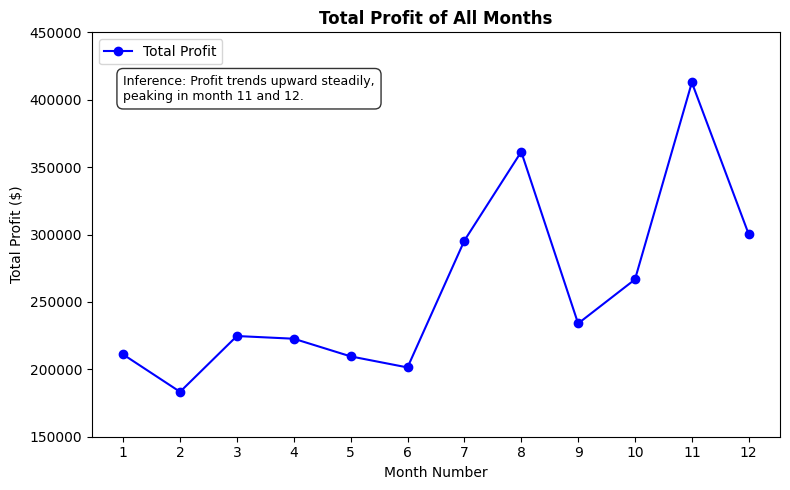

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(df['month_number'], df['total_profit'], marker='o', color='b', label='Total Profit')
plt.title('Total Profit of All Months', fontsize=12, fontweight='bold')
plt.xlabel('Month Number')
plt.ylabel('Total Profit ($)')
plt.xticks(df['month_number'])
plt.ylim(150000, 450000)
plt.legend(loc='upper left')
plt.text(1, 400000, 'Inference: Profit trends upward steadily,\npeaking in month 11 and 12.', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8), fontsize=9)
plt.tight_layout()
plt.show()

##### This line chart shows the company's monthly total profit over one year. Profit remains fairly stable during the first six months, then increases sharply in July and August. Although there is a temporary decline in September, profits recover in October and reach the highest value in November. December also records strong profit. Overall, the company demonstrates positive growth in profitability toward the end of the year, indicating stronger sales performance during the last quarter.
#### =============================================================================

### <span style="color:Green"> Q.2) Read toothpaste sales data of each month and show it using a scatter plot. Also, add a grid in the plot. gridline style should “–“..</span>


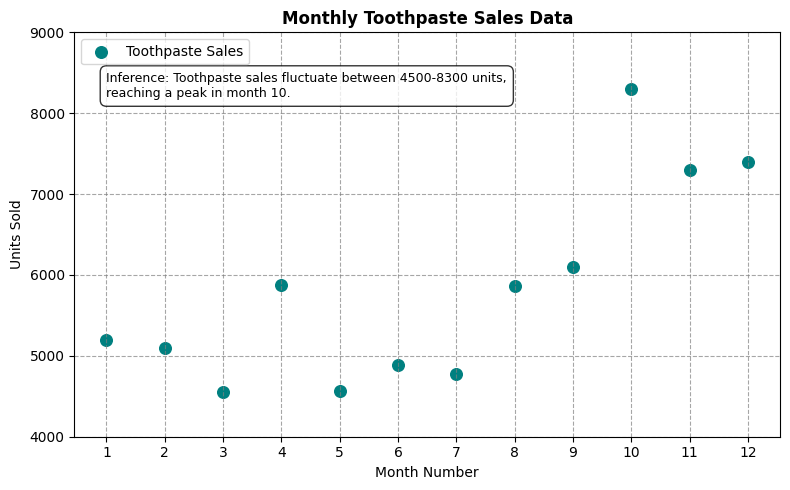

In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(df['month_number'], df['toothpaste'], color='teal', label='Toothpaste Sales', s=70)
plt.title('Monthly Toothpaste Sales Data', fontsize=12, fontweight='bold')
plt.xlabel('Month Number')
plt.ylabel('Units Sold')
plt.xticks(df['month_number'])
plt.ylim(4000, 9000)
plt.grid(True, linestyle='--', color='gray', alpha=0.7)
plt.legend(loc='upper left')
plt.text(1, 8200, 'Inference: Toothpaste sales fluctuate between 4500-8300 units,\nreaching a peak in month 10.', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8), fontsize=9)
plt.tight_layout()
plt.show()

##### This scatter plot displays the monthly toothpaste sales throughout the year. The sales fluctuate across the months, with lower sales observed during the first half of the year. From Month 8 onward, sales show a noticeable upward trend, reaching the highest value in Month 10. Although sales decline slightly in the last two months, they remain comparatively high. Overall, toothpaste sales improve significantly in the second half of the year, indicating increased customer demand.
#### ============================================================================

### <span style="color:Green"> Q.3) Plot the Total profit column with Boxplot(horizontal, Vertical, Notch), Histogram, barplot, Dotchart.</span>


#### <span style="color:Blue"> Q.3 (a) Horizontal Boxplot Of Total Profit</span>

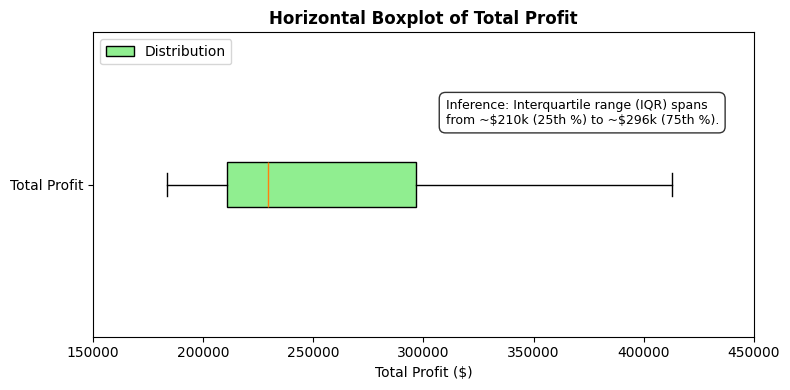

In [24]:
plt.figure(figsize=(8, 4))

# 1. Used tick_labels instead of labels (fixes deprecation warning)
plt.boxplot(df['total_profit'], vert=False, tick_labels=['Total Profit'], patch_artist=True, boxprops=dict(facecolor='lightgreen'))

plt.title('Horizontal Boxplot of Total Profit', fontsize=12, fontweight='bold')
plt.xlabel('Total Profit ($)', fontsize=10)
plt.xlim(150000, 450000)
plt.legend(['Distribution'], loc='upper left')

# 2. Escaped dollar signs using \$ (fixes the ValueError math parsing error)
plt.text(310000, 1.2, 'Inference: Interquartile range (IQR) spans\nfrom ~\\$210k (25th %) to ~\\$296k (75th %).', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8), fontsize=9)

plt.tight_layout()
plt.show()

##### Conclusion: This horizontal boxplot summarizes the distribution of the company's total profit. The median profit is around 229,000 dollers and the middle 50% of the profit values lie between approximately 210,000 dollers and 296,000 dollers. The profit ranges from about 180,000 dollers to 412,000 dollers with no significant outliers. Overall, the company maintains a relatively consistent profit distribution, with a few higher-profit months extending the upper range.
#### ===============================================================================

#### <span style="color:Blue"> Q.3 (b) Vertical Boxplot Of Total Profit</span>


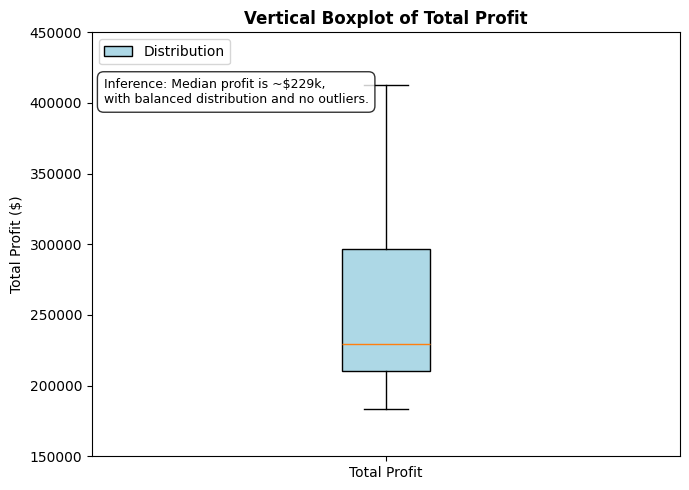

In [25]:
plt.figure(figsize=(7, 5))
plt.boxplot(df['total_profit'], tick_labels=['Total Profit'], patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Vertical Boxplot of Total Profit', fontsize=12, fontweight='bold')
plt.ylabel('Total Profit ($)')
plt.ylim(150000, 450000)
plt.legend(['Distribution'], loc='upper left')
plt.text(0.52, 400000, 'Inference: Median profit is ~$229k,\nwith balanced distribution and no outliers.', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8), fontsize=9)
plt.tight_layout()
plt.show()

##### This vertical boxplot summarizes the distribution of the company's total profit. The median profit is approximately 229,000 dollers indicating the middle profit value across all months. The middle 50% of the profit values lie between about 210,000 dollers and 296,000 dollers. The data ranges from around 180,000 to 412,000 dollers and there are no significant outliers. Overall, the company's monthly profit is relatively consistent, with higher profits observed in a few months.
#### =============================================================================

#### <span style="color:Blue"> Q3.(c) Notched Boxplot Of Total Profit</span>

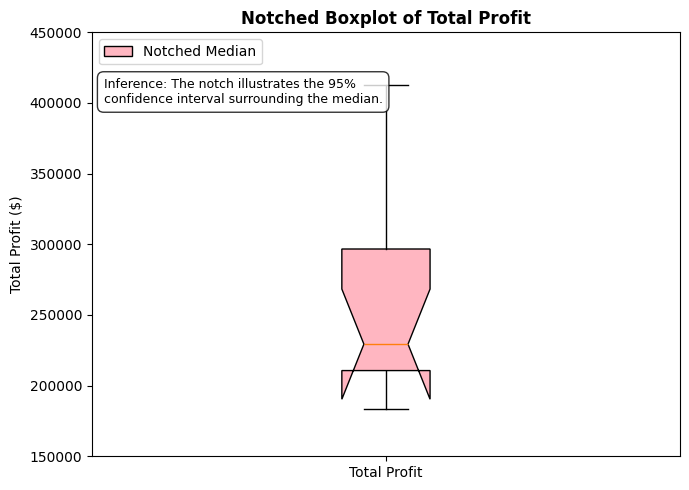

In [28]:
plt.figure(figsize=(7, 5))
plt.boxplot(df['total_profit'], notch=True, tick_labels=['Total Profit'], patch_artist=True, boxprops=dict(facecolor='lightpink'))
plt.title('Notched Boxplot of Total Profit', fontsize=12, fontweight='bold')
plt.ylabel('Total Profit ($)')
plt.ylim(150000, 450000)
plt.legend(['Notched Median'], loc='upper left')
plt.text(0.52, 400000, 'Inference: The notch illustrates the 95%\nconfidence interval surrounding the median.', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8), fontsize=9)
plt.tight_layout()
plt.show()

##### Objective: "A notched boxplot is used to visualize the median and its confidence interval. It is especially useful when comparing the medians of different datasets because overlapping notches suggest the medians may not be significantly different."
##### This notched boxplot shows the distribution of the company's total profit. The median profit is around 229,000 dollers and the notch highlights the approximate 95% confidence interval around the median. The middle 50% of the profit values are concentrated between about 210,000 and 296,000 dollers. There are no significant outliers, indicating a fairly consistent distribution of monthly profits.
#### ============================================================================

#### <span style="color:Blue"> Q3.(d) Histogram Of Total Profit </span>

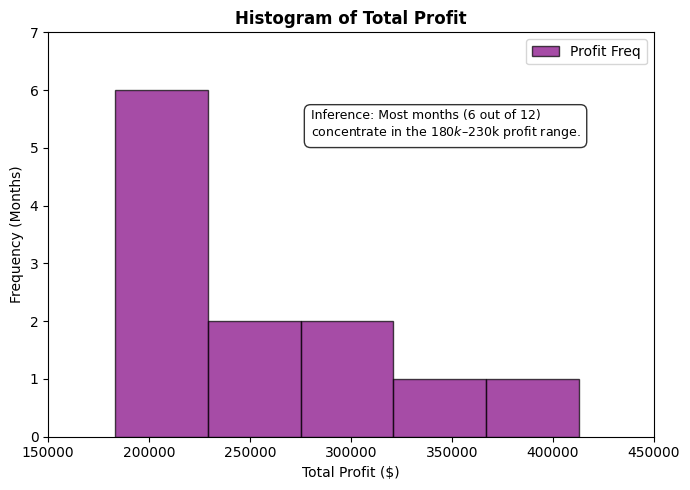

In [29]:
plt.figure(figsize=(7, 5))
plt.hist(df['total_profit'], bins=5, color='purple', alpha=0.7, edgecolor='black', label='Profit Freq')
plt.title('Histogram of Total Profit', fontsize=12, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('Frequency (Months)')
plt.xlim(150000, 450000)
plt.ylim(0, 7)
plt.legend(loc='upper right')
plt.text(280000, 5.2, 'Inference: Most months (6 out of 12)\nconcentrate in the $180k–$230k profit range.', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8), fontsize=9)
plt.tight_layout()
plt.show()

##### Objective: The objective of this graph is to show how the total profit is distributed across different profit ranges. A histogram helps identify which profit range occurs most frequently.
##### This histogram shows the frequency distribution of the company's monthly total profit. Most months (6 out of 12) recorded profits between approximately 180,000 and 230,000 dollers making this the most common profit range. Higher profit values occurred in fewer months, indicating that exceptionally high profits were less frequent. Overall, the company's profits are concentrated in the lower to middle profit ranges, with only a few months achieving very high profits.
#### ===============================================================================

#### <span style="color:Blue"> Q3.(e) Barplot Of Total Profit </span>

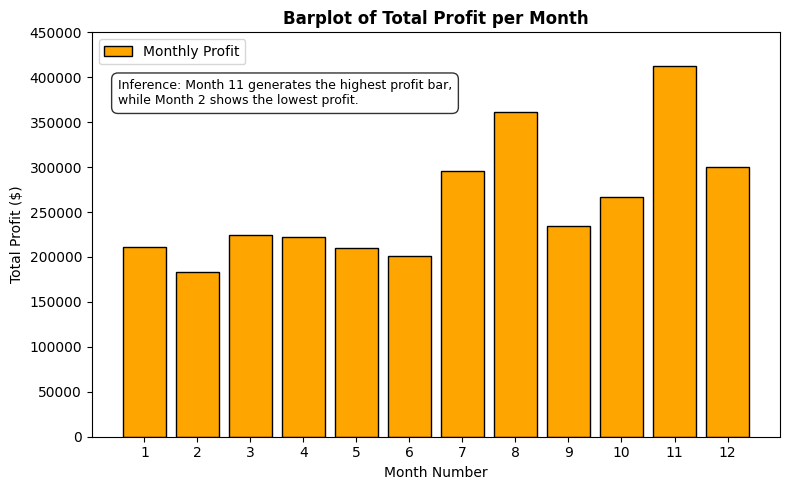

In [38]:
plt.figure(figsize=(8, 5))
plt.bar(df['month_number'], df['total_profit'], color='orange', edgecolor='black', label='Monthly Profit')
plt.title('Barplot of Total Profit per Month', fontsize=12, fontweight='bold')
plt.xlabel('Month Number')
plt.ylabel('Total Profit ($)')
plt.xticks(df['month_number'])
plt.ylim(0, 450000)
plt.legend(loc='upper left')
plt.text(0.5, 370000, 'Inference: Month 11 generates the highest profit bar,\nwhile Month 2 shows the lowest profit.', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8), fontsize=9)
plt.tight_layout()
plt.show()

##### This bar plot compares the company's monthly total profit. Month 11 recorded the highest profit, while Month 2 had the lowest. The profits remain relatively stable during the first half of the year, followed by a noticeable increase in the later months. Overall, the company achieves stronger profitability in the second half of the year, with peak performance toward the end of the year.
#### ==================================================================================

#### <span style="color:Blue"> Q3.(f) Dotchart Of Total Profit </span>

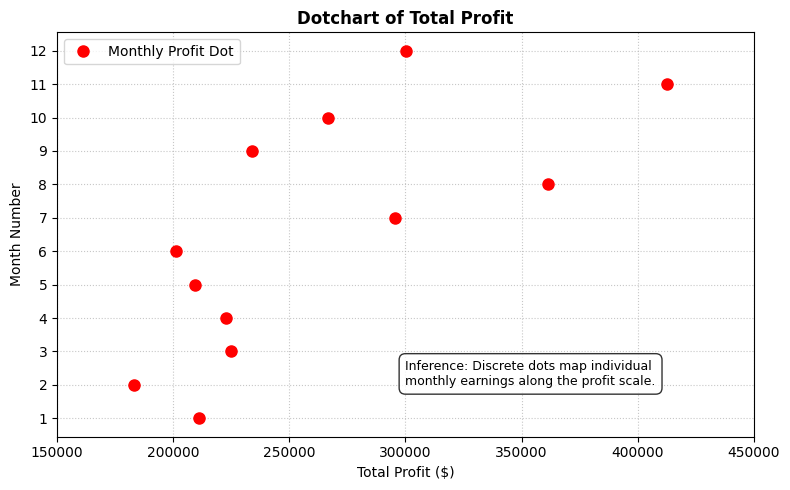

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(df['total_profit'], df['month_number'], 'ro', label='Monthly Profit Dot', markersize=8)
plt.title('Dotchart of Total Profit', fontsize=12, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('Month Number')
plt.yticks(df['month_number'])
plt.xlim(150000, 450000)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper left')
plt.text(300000, 2, 'Inference: Discrete dots map individual\nmonthly earnings along the profit scale.', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8), fontsize=9)
plt.tight_layout()
plt.show()

##### This dot chart displays the company's monthly total profit using individual data points. Each dot represents one month's profit, making it easy to compare values across the year. Month 11 recorded the highest profit, while Month 2 had the lowest. Most profits are concentrated between 180,000 and 300,000 dollers with higher profits observed in the later months. Overall, the chart indicates stronger business performance toward the end of the year.
#### ====================================================================================

### <span style="color:Green"> Q.4) Do the scatterplot on Total profit & Month_number column.</span>


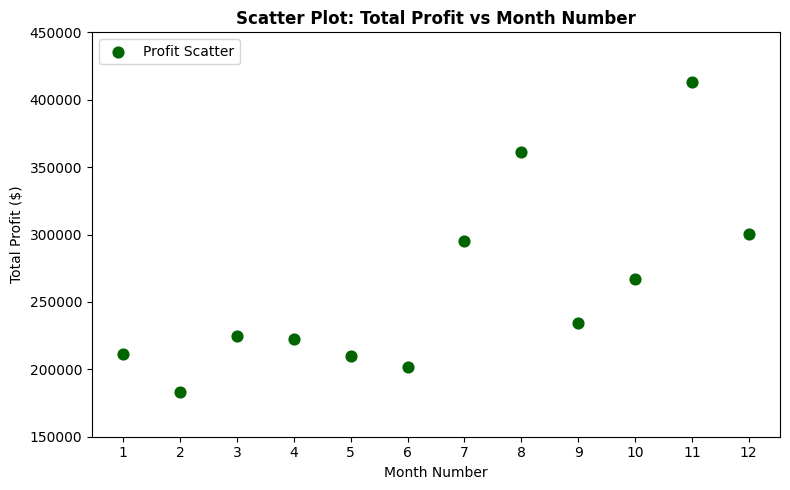

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(df['month_number'], df['total_profit'], color='darkgreen', s=60, label='Profit Scatter')
plt.title('Scatter Plot: Total Profit vs Month Number', fontsize=12, fontweight='bold')
plt.xlabel('Month Number')
plt.ylabel('Total Profit ($)')
plt.xticks(df['month_number'])
plt.ylim(150000, 450000)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

##### This scatter plot shows the relationship between the month number and the company's total profit. Each point represents the profit earned in a specific month. The profits remain relatively stable during the first six months, then increase significantly in the second half of the year. Month 11 records the highest profit, while Month 2 has the lowest. Overall, the company experiences stronger profitability toward the end of the year.
#### ===============================================================================

### <span style="color:Green"> Q.5)  Plot the Total profit with format” red square -” (“rs-”) and only “red circles “ (“ro”).</span>


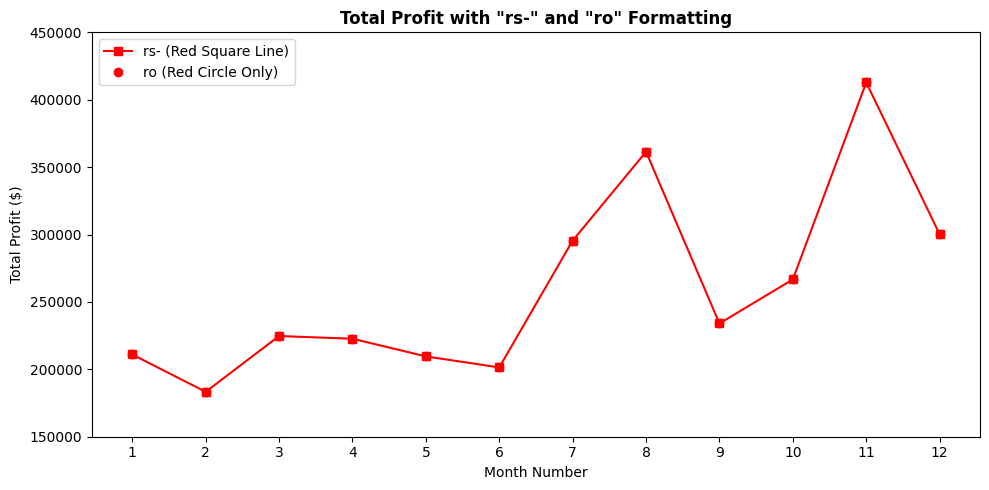

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(df['month_number'], df['total_profit'], 'rs-', label='rs- (Red Square Line)')
plt.plot(df['month_number'], df['total_profit'], 'ro', label='ro (Red Circle Only)')
plt.title('Total Profit with "rs-" and "ro" Formatting', fontsize=12, fontweight='bold')
plt.xlabel('Month Number')
plt.ylabel('Total Profit ($)')
plt.xticks(df['month_number'])
plt.ylim(150000, 450000)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

##### This graph displays the company's monthly total profit using different Matplotlib formatting styles. The red square markers connected by a line show the trend in profit over the months, while the red circle markers emphasize each individual data point. The company experiences steady profits in the first half of the year, followed by significant growth in the second half. Month 11 records the highest profit, while Month 2 records the lowest.
#### ======================================================================================

### <span style="color:Green"> Q.6) Read sales data of bathing soap of all months and show it using a bar chart.</span>


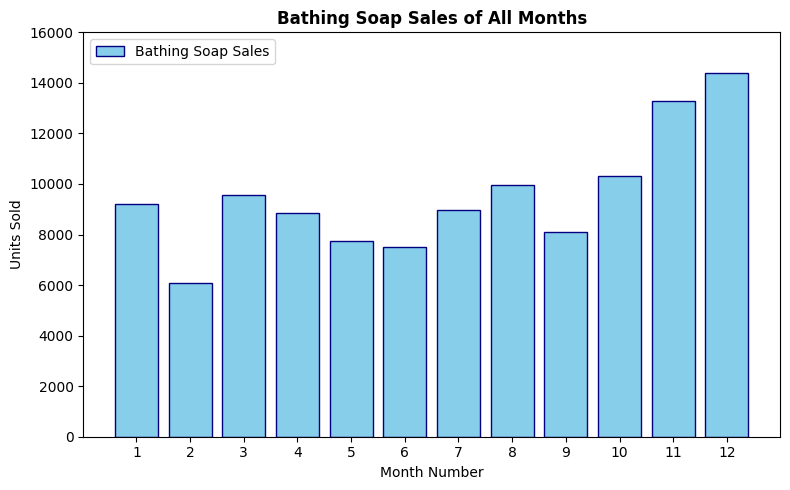

In [27]:
plt.figure(figsize=(8, 5))
plt.bar(df['month_number'], df['bathingsoap'], color='skyblue', edgecolor='navy', label='Bathing Soap Sales')
plt.title('Bathing Soap Sales of All Months', fontsize=12, fontweight='bold')
plt.xlabel('Month Number')
plt.ylabel('Units Sold')
plt.xticks(df['month_number'])
plt.ylim(0, 16000)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

##### This bar chart compares the monthly sales of bathing soap throughout the year. Sales are relatively stable during the first half of the year, with the lowest sales occurring in Month 2. From Month 8 onward, sales gradually increase, reaching the highest level in Month 12. Overall, the company experiences stronger bathing soap sales in the last quarter of the year, indicating increased customer demand toward the end of the year.
#### ==========================================================================